# Chapter 14 — Expanding the toolkit

This notebook accompanies **Chapter 14** of *Inference in Statistical Modelling and Machine Learning*.

The final chapter is a survey of three ways to expand the core toolkit:

1. **Flexible prediction function families** (§14.1) — splines, GAMs, and local regression go beyond global polynomials by fitting *locally*.
2. **Differential equation models** (§14.2) — treat the solution of an ODE as a parametric family; fit it using standard likelihood methods.
3. **Generative language models** (§14.3) — GPT is an autoregressive next-token predictor; we sketch how it fits into the inference framework.

We code up ideas 1 and 2; idea 3 is discussed conceptually.

---
## Key formulae

**Smoothing spline** (§14.1): penalise the curvature of $g$,
$$l(\boldsymbol{\theta}) = \sum_{i=1}^{n}\bigl(y_i - g(x_i;\boldsymbol{\theta})\bigr)^2
   + \lambda\int\bigl(\partial_t^2 g(t;\boldsymbol{\theta})\bigr)^2\,dt.$$

**Local regression** (§14.1): at query point $x_0$, weight training points by a Gaussian kernel
$K_\lambda(x_0,x)=\exp\!\bigl(-\|x-x_0\|^2/\lambda^2\bigr)$ and minimise
$$l(\boldsymbol{\theta};x_0) = \sum_{i=1}^{n} K_\lambda(x_0,x_i)\,(y_i - g(x_i;\boldsymbol{\theta}))^2.$$

**Logistic growth ODE** (§14.2):
$$\frac{dn}{dt} = rn\!\left(1-\frac{n}{K}\right) \;\Longrightarrow\;
g(t;\boldsymbol{\theta}) = \frac{Kn_0}{n_0 + (K-n_0)\,e^{-rt}}.$$
Fit to count data via $N_i\sim\text{Poisson}(g(t_i;\boldsymbol{\theta}))$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.interpolate import UnivariateSpline
from scipy.special import gammaln

rng = np.random.default_rng(42)

---
## §14.1 Local regression from scratch

**Why not global polynomials?**  A high-degree polynomial is fitted globally, so adjusting it to
match the data near one $x$ value forces it to oscillate wildly elsewhere.

**Local linear regression** avoids this by fitting a different linear function at every query point
$x_0$.  Training points closer to $x_0$ are given more weight through the Gaussian kernel
$K_\lambda(x_0, x) = \exp(-(x-x_0)^2/\lambda^2)$.
The local fit is the solution to a weighted least-squares problem — nothing more exotic than that.

The **bandwidth** $\lambda$ controls the bias–variance trade-off:
- Small $\lambda$: each prediction depends on only a few nearby points → low bias, high variance (chases noise).
- Large $\lambda$: nearly all points contribute equally → low variance, high bias (over-smoothes).

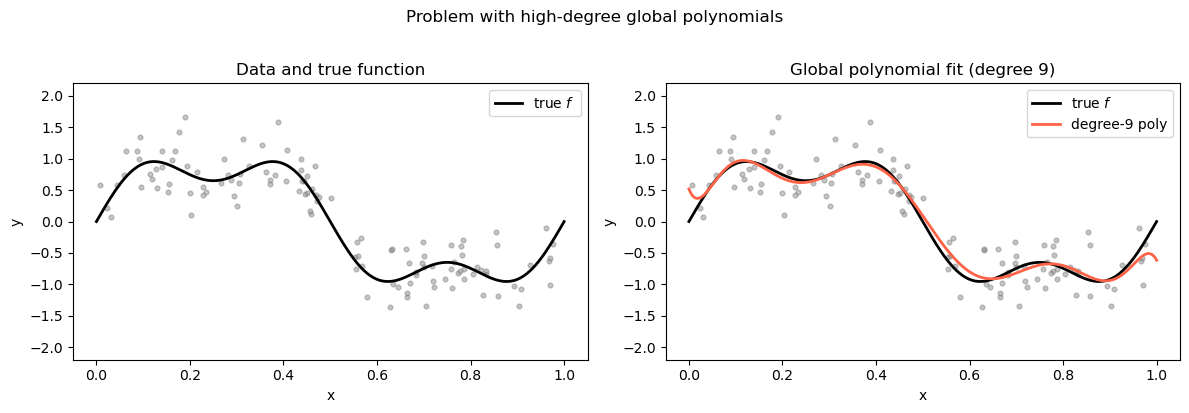

In [2]:
# --- Generate training data from a two-humped curve ---
def f_true(x):
    return np.sin(2 * np.pi * x) + 0.35 * np.sin(6 * np.pi * x)

n = 120
x_train = np.sort(rng.uniform(0, 1, n))
y_train = f_true(x_train) + rng.normal(0, 0.3, n)

x_grid = np.linspace(0, 1, 300)

# Compare: degree-9 global polynomial vs the true function
coeffs = np.polyfit(x_train, y_train, deg=9)
y_poly = np.polyval(coeffs, x_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax in axes:
    ax.scatter(x_train, y_train, s=12, alpha=0.45, color='grey')
    ax.plot(x_grid, f_true(x_grid), 'k', linewidth=2, label='true $f$')

axes[0].set_title('Data and true function')
axes[0].legend()

axes[1].plot(x_grid, y_poly, 'tomato', linewidth=2, label='degree-9 poly')
axes[1].set_title('Global polynomial fit (degree 9)')
axes[1].legend()

for ax in axes:
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_ylim(-2.2, 2.2)

plt.suptitle('Problem with high-degree global polynomials', y=1.02)
plt.tight_layout()
plt.show()

In [3]:
# --- Local linear regression: weighted least squares at each query point ---

def local_linear_predict(x_train, y_train, x0_grid, lam):
    """Predict at every x0 in x0_grid using local linear WLS with Gaussian kernel."""
    preds = np.empty(len(x0_grid))
    X = np.column_stack([np.ones(len(x_train)), x_train])  # design matrix [1, x]
    for i, x0 in enumerate(x0_grid):
        w = np.exp(-((x_train - x0) ** 2) / lam ** 2)
        W_sqrt = np.sqrt(w)
        # Weighted normal equations via QR: minimise ||W^{1/2}(y - X beta)||^2
        Xw = X * W_sqrt[:, None]
        yw = y_train * W_sqrt
        beta, *_ = np.linalg.lstsq(Xw, yw, rcond=None)
        preds[i] = beta[0] + beta[1] * x0
    return preds

print("local_linear_predict defined.")

local_linear_predict defined.


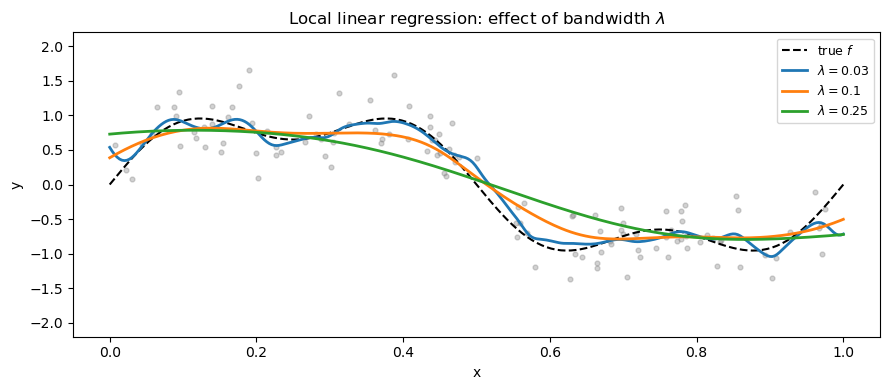

In [4]:
# --- Bandwidth sweep: see how lambda controls smoothness ---

lambdas = [0.03, 0.10, 0.25]
colours = ['C0', 'C1', 'C2']

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(x_train, y_train, s=12, alpha=0.35, color='grey')
ax.plot(x_grid, f_true(x_grid), 'k--', linewidth=1.5, label='true $f$')

for lam, col in zip(lambdas, colours):
    y_pred = local_linear_predict(x_train, y_train, x_grid, lam)
    ax.plot(x_grid, y_pred, color=col, linewidth=2,
            label=r'$\lambda=' + f'{lam}$')

ax.set_xlabel('x'); ax.set_ylabel('y')
ax.set_title(r'Local linear regression: effect of bandwidth $\lambda$')
ax.legend(fontsize=9)
ax.set_ylim(-2.2, 2.2)
plt.tight_layout()
plt.show()

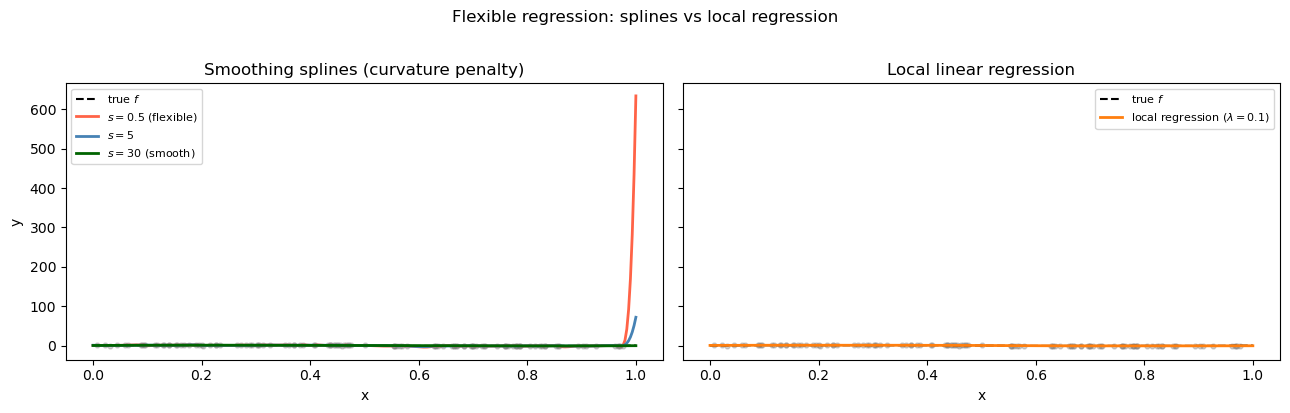

In [5]:
# --- Compare with smoothing splines (scipy) ---
# scipy's UnivariateSpline minimises sum-of-squared residuals + integrated curvature.
# The smoothing parameter s bounds the allowed residual: larger s => smoother.

s_values = [0.5, 5.0, 30.0]
labels   = [r'$s=0.5$ (flexible)', r'$s=5$', r'$s=30$ (smooth)']
cols2    = ['tomato', 'steelblue', 'darkgreen']

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

# Left: smoothing splines
ax = axes[0]
ax.scatter(x_train, y_train, s=12, alpha=0.35, color='grey')
ax.plot(x_grid, f_true(x_grid), 'k--', linewidth=1.5, label='true $f$')
for s, lab, col in zip(s_values, labels, cols2):
    spl = UnivariateSpline(x_train, y_train, s=s)
    ax.plot(x_grid, spl(x_grid), color=col, linewidth=2, label=lab)
ax.set_title('Smoothing splines (curvature penalty)')
ax.legend(fontsize=8); ax.set_xlabel('x'); ax.set_ylabel('y')

# Right: local regression with best lambda for comparison
ax = axes[1]
ax.scatter(x_train, y_train, s=12, alpha=0.35, color='grey')
ax.plot(x_grid, f_true(x_grid), 'k--', linewidth=1.5, label='true $f$')
y_loc = local_linear_predict(x_train, y_train, x_grid, lam=0.10)
ax.plot(x_grid, y_loc, 'C1', linewidth=2, label=r'local regression ($\lambda=0.1$)')
ax.set_title('Local linear regression')
ax.legend(fontsize=8); ax.set_xlabel('x')

plt.suptitle('Flexible regression: splines vs local regression', y=1.02)
plt.tight_layout()
plt.show()

---
## §14.2 Differential equations as function families

Many scientific models are expressed as differential equations.  The book's example is a wildlife
population governed by **logistic growth** (§14.2).

Let $n(t)$ denote expected population size at time $t$:
$$\frac{dn}{dt} = rn\!\left(1-\frac{n}{K}\right),\qquad n(0)=n_0.$$

The exact solution is the three-parameter family
$$g(t;\boldsymbol{\theta}) = \frac{Kn_0}{n_0+(K-n_0)\,e^{-rt}},\qquad
\boldsymbol{\theta}=(n_0,r,K).$$

**Observation model.** Actual population counts are noisy.  We model each count as
$N_i \sim \text{Poisson}(g(t_i;\boldsymbol{\theta}))$, giving log-likelihood
$$\ell(\boldsymbol{\theta}) = \sum_{i=1}^{M}\bigl[n_i\ln g(t_i;\boldsymbol{\theta}) - g(t_i;\boldsymbol{\theta})\bigr] + \text{const.}$$

> **Book link — §14.2.** The key insight is that $g(t;\boldsymbol{\theta})$ is just a parametric function family.
> That it originates from an ODE does not change the inference procedure at all.

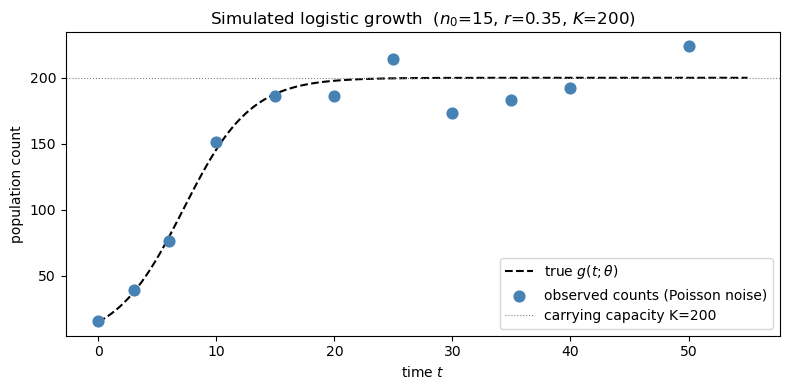

t_obs: [ 0.  3.  6. 10. 15. 20. 25. 30. 35. 40. 50.]
n_obs: [ 16  39  76 151 186 186 214 173 183 192 224]
mu   : [ 15.   37.6  79.7 145.7 187.8 197.8 199.6 199.9 200.  200.  200. ]


In [6]:
# --- Simulate logistic growth with Poisson noise ---

def logistic_growth(t, n0, r, K):
    return K * n0 / (n0 + (K - n0) * np.exp(-r * t))

# True parameters
N0_TRUE, R_TRUE, K_TRUE = 15.0, 0.35, 200.0

t_obs = np.array([0, 3, 6, 10, 15, 20, 25, 30, 35, 40, 50], dtype=float)
mu_true = logistic_growth(t_obs, N0_TRUE, R_TRUE, K_TRUE)
n_obs   = rng.poisson(mu_true)     # observed counts

t_fine = np.linspace(0, 55, 300)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_fine, logistic_growth(t_fine, N0_TRUE, R_TRUE, K_TRUE),
        'k--', linewidth=1.5, label='true $g(t;\\theta)$')
ax.scatter(t_obs, n_obs, s=60, zorder=5, color='steelblue',
           label='observed counts (Poisson noise)')
ax.axhline(K_TRUE, color='grey', linestyle=':', linewidth=0.8,
           label=f'carrying capacity K={K_TRUE:.0f}')
ax.set_xlabel('time $t$'); ax.set_ylabel('population count')
ax.set_title(f'Simulated logistic growth  ($n_0$={N0_TRUE:.0f}, $r$={R_TRUE}, $K$={K_TRUE:.0f})')
ax.legend()
plt.tight_layout()
plt.show()

print("t_obs:", t_obs)
print("n_obs:", n_obs)
print("mu   :", np.round(mu_true, 1))

MLE:   n̂₀ = 15.3   r̂ = 0.352   K̂ = 196.3
True:  n₀ = 15.0     r = 0.35    K = 200.0


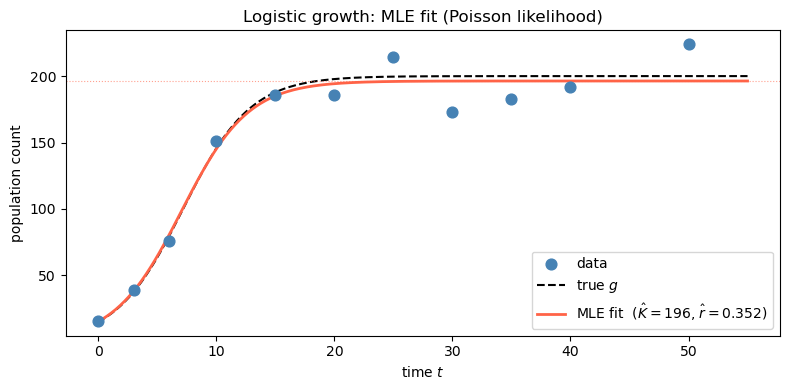

In [7]:
# --- MLE: minimise negative Poisson log-likelihood ---

def neg_log_lik(params, t_obs, n_obs):
    n0, r, K = params
    if n0 <= 0 or r <= 0 or K <= n0:     # parameter constraints
        return np.inf
    mu = logistic_growth(t_obs, n0, r, K)
    mu = np.maximum(mu, 1e-10)           # guard against log(0)
    # Poisson log-likelihood (drop the constant log(n!) term)
    ll = np.sum(n_obs * np.log(mu) - mu)
    return -ll

result = minimize(
    neg_log_lik, [20.0, 0.30, 150.0],
    args=(t_obs, n_obs),
    method='Nelder-Mead',
    options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 20000}
)

n0_mle, r_mle, K_mle = result.x
print(f"MLE:   n̂₀ = {n0_mle:.1f}   r̂ = {r_mle:.3f}   K̂ = {K_mle:.1f}")
print(f"True:  n₀ = {N0_TRUE}     r = {R_TRUE}    K = {K_TRUE}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(t_obs, n_obs, s=60, color='steelblue', zorder=5, label='data')
ax.plot(t_fine, logistic_growth(t_fine, N0_TRUE, R_TRUE, K_TRUE),
        'k--', linewidth=1.5, label='true $g$')
ax.plot(t_fine, logistic_growth(t_fine, n0_mle, r_mle, K_mle),
        'tomato', linewidth=2,
        label=f'MLE fit  ($\\hat{{K}}={K_mle:.0f}$, $\\hat{{r}}={r_mle:.3f}$)')
ax.axhline(K_mle, color='tomato', linestyle=':', linewidth=0.8, alpha=0.6)
ax.set_xlabel('time $t$'); ax.set_ylabel('population count')
ax.set_title('Logistic growth: MLE fit (Poisson likelihood)')
ax.legend()
plt.tight_layout()
plt.show()

---
## §14.3 Generative language models (conceptual overview)

The chapter closes by connecting **GPT-style language models** to the inference framework
built up throughout the book (§14.3).

**The key factorisation.** Any distribution over a word sequence $W_1,\ldots,W_N$ can be written
$$f_{W_1,\ldots,W_N}(w_1,\ldots,w_N)
  = f_{W_1}(w_1)\prod_{i=2}^{N} f_{W_i\mid W_1,\ldots,W_{i-1}}(w_i\mid w_1,\ldots,w_{i-1}).$$

**The learning problem.** We want to learn the conditional $f_{W_i\mid W_1,\ldots,W_{i-1}}$ — a
function from context to a probability vector over the vocabulary.  This is exactly the
multinomial classification problem from Chapter 11, with $g_k(\mathbf{x})$ being the
probability of word $k$ given context $\mathbf{x}$.

**Training.** Given a large corpus, GPT minimises the **cross-entropy loss**
$$l(\boldsymbol{\theta}) = -\sum_{(\mathbf{x},y)\in D} \log g_y(\mathbf{x}),$$
where $\mathbf{x}=(w_1,\ldots,w_p)$ is the context and $y=w_{p+1}$ is the next word.
This is just maximum likelihood for the Categorical distribution.

**Generation.** To sample new text: draw $w_1$ from the marginal, then $w_2$ from
$f_{W_2\mid W_1}(\cdot\mid w_1)$, and so on (**autoregressive** sampling).

**The book's message.** GPT is a very large transformer network — a sophisticated function
approximator — trained by standard maximum-likelihood.  The same inference pipeline we have
used throughout the course (write down a model, write down a likelihood, optimise) drives
the most powerful AI systems in the world.

---
## Exercises

### Exercise 1 — Bandwidth selection by hold-out cross-validation

Split the 120 training points into a fitting set (80%) and a validation set (20%).  Compute
the local-regression validation MSE for each $\lambda \in \{0.02,\, 0.05,\, 0.10,\, 0.15,\, 0.25,\, 0.40\}$.
Which bandwidth minimises validation error?  Is it close to the visually 'best' fit from the
bandwidth sweep above?

### Exercise 2 — Profile likelihood for the carrying capacity

The carrying capacity $K$ is the most scientifically interesting parameter.  Construct its
**profile log-likelihood** by maximising $\ell(n_0, r, K)$ over $(n_0, r)$ for each fixed $K$:
$$\ell_\text{prof}(K) = \max_{n_0,\,r}\;\ell(n_0,r,K).$$

Plot $\ell_\text{prof}(K) - \max_K \ell_\text{prof}(K)$ and find the 95% profile confidence
interval (the set where $2[\max \ell - \ell_\text{prof}(K)] < \chi^2_{1,0.95} = 3.84$,
i.e.&nbsp;where the relative profile log-likelihood exceeds $-1.92$).

lambda=0.02   validation MSE = 0.1231
lambda=0.05   validation MSE = 0.1158
lambda=0.10   validation MSE = 0.1216
lambda=0.15   validation MSE = 0.1397
lambda=0.25   validation MSE = 0.1882
lambda=0.40   validation MSE = 0.2488

Best lambda = 0.05


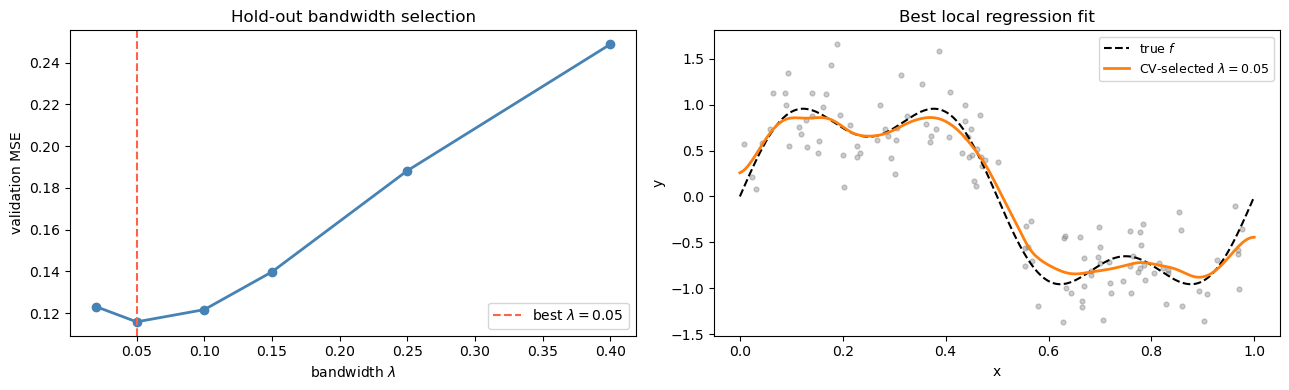

In [8]:
# ── Solution to Exercise 1: hold-out bandwidth selection ──────────────────────

idx    = rng.permutation(n)
n_fit  = int(0.8 * n)
x_fit, y_fit = x_train[idx[:n_fit]], y_train[idx[:n_fit]]
x_val, y_val = x_train[idx[n_fit:]], y_train[idx[n_fit:]]

lambdas_cv = [0.02, 0.05, 0.10, 0.15, 0.25, 0.40]
mse_val    = []

for lam in lambdas_cv:
    y_pred = local_linear_predict(x_fit, y_fit, x_val, lam)
    mse    = np.mean((y_val - y_pred) ** 2)
    mse_val.append(mse)
    print(f"lambda={lam:.2f}   validation MSE = {mse:.4f}")

best_lam = lambdas_cv[int(np.argmin(mse_val))]
print(f"\nBest lambda = {best_lam}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(lambdas_cv, mse_val, 'o-', color='steelblue', linewidth=2)
axes[0].axvline(best_lam, color='tomato', linestyle='--',
                label=f'best $\\lambda = {best_lam}$')
axes[0].set_xlabel(r'bandwidth $\lambda$')
axes[0].set_ylabel('validation MSE')
axes[0].set_title('Hold-out bandwidth selection')
axes[0].legend()

# Best fit on the full training set
y_best = local_linear_predict(x_train, y_train, x_grid, best_lam)
axes[1].scatter(x_train, y_train, s=12, alpha=0.4, color='grey')
axes[1].plot(x_grid, f_true(x_grid), 'k--', linewidth=1.5, label='true $f$')
axes[1].plot(x_grid, y_best, 'C1', linewidth=2,
             label=f'CV-selected $\\lambda={best_lam}$')
axes[1].set_xlabel('x'); axes[1].set_ylabel('y')
axes[1].set_title('Best local regression fit')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

True K      = 200.0
MLE  K̂      = 196.3
95% profile CI for K: [186.1, 207.3]


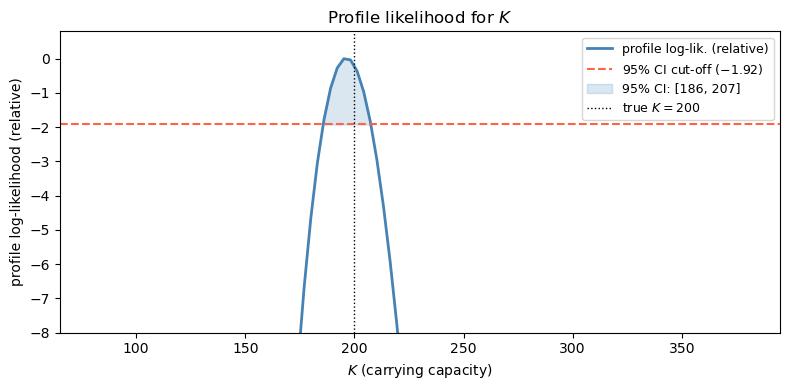

In [9]:
# ── Solution to Exercise 2: profile likelihood for K ──────────────────────────

K_grid   = np.linspace(80, 380, 100)
prof_ll  = np.empty(len(K_grid))

for j, K_fix in enumerate(K_grid):
    def neg_ll_fixed_K(params2):
        n0, r = params2
        if n0 <= 0 or r <= 0 or K_fix <= n0:
            return np.inf
        mu = logistic_growth(t_obs, n0, r, K_fix)
        mu = np.maximum(mu, 1e-10)
        return -np.sum(n_obs * np.log(mu) - mu)

    res = minimize(neg_ll_fixed_K, [15.0, 0.35],
                   method='Nelder-Mead',
                   options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 10000})
    prof_ll[j] = -res.fun

# Relative profile log-likelihood
prof_ll_rel = prof_ll - prof_ll.max()

# 95% CI: region where prof_ll_rel > -1.92
ci_mask  = prof_ll_rel > -1.92
K_ci_lo  = K_grid[ci_mask].min()
K_ci_hi  = K_grid[ci_mask].max()

print(f"True K      = {K_TRUE}")
print(f"MLE  K̂      = {K_mle:.1f}")
print(f"95% profile CI for K: [{K_ci_lo:.1f}, {K_ci_hi:.1f}]")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(K_grid, prof_ll_rel, 'steelblue', linewidth=2,
        label='profile log-lik. (relative)')
ax.axhline(-1.92, color='tomato', linestyle='--',
           label=r'95% CI cut-off ($-1.92$)')
ax.fill_between(K_grid, prof_ll_rel, -1.92,
                where=ci_mask, alpha=0.2, color='steelblue',
                label=f'95% CI: [{K_ci_lo:.0f}, {K_ci_hi:.0f}]')
ax.axvline(K_TRUE, color='k', linestyle=':', linewidth=1,
           label=f'true $K={K_TRUE:.0f}$')
ax.set_xlabel('$K$ (carrying capacity)')
ax.set_ylabel('profile log-likelihood (relative)')
ax.set_title('Profile likelihood for $K$')
ax.set_ylim(-8, 0.8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()